In [ ]:
!pip install xgboost scikit-learn

In [ ]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [48]:
file_path = '/content/drive/MyDrive/FYP/Datasets/machine_learning_balance_CIC-IDS-2017_data.csv'
df = pd.read_csv(file_path)
print(df)

         flow_duration  total_fwd_packets  total_backward_packets  \
0               1001.0                4.0                     0.0   
1          101613739.0                8.0                     5.0   
2             285697.0                2.0                     2.0   
3                196.0                2.0                     2.0   
4              60643.0                1.0                     1.0   
...                ...                ...                     ...   
1113387      1216777.0               19.0                    20.0   
1113388    115728534.0               20.0                    17.0   
1113389          231.0                2.0                     2.0   
1113390      1785987.0                5.0                     0.0   
1113391        84484.0                2.0                     2.0   

          flow_bytes/s  flow_packets/s  packet_length_mean  packet_length_std  \
0             0.000000     3996.003996            0.000000           0.000000   
1        

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
X = df.drop('label', axis=1)  # Features
y = df['label']               # Target

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print("Any NaNs in features?", X_train.isnull().any().any())
print("Any infinite values in features?", X_train.replace([float('inf'), -float('inf')], float('nan')).isnull().any().any())

Any NaNs in features? False
Any infinite values in features? True


In [ ]:
# Replace infinite values with NaN
X_train = X_train.replace([float('inf'), -float('inf')], pd.NA)
X_test = X_test.replace([float('inf'), -float('inf')], pd.NA)

# Then fill NaNs (e.g., with 0 or column mean)
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

<ipython-input-37-3f4a5ea266e7>:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train = X_train.fillna(0)
<ipython-input-37-3f4a5ea266e7>:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_test = X_test.fillna(0)


In [ ]:
model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [21:19:32] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

In [ ]:
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Detailed metrics
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9863

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99    111397
           1       0.99      0.99      0.99    111282

    accuracy                           0.99    222679
   macro avg       0.99      0.99      0.99    222679
weighted avg       0.99      0.99      0.99    222679


Confusion Matrix:
 [[109808   1589]
 [  1472 109810]]


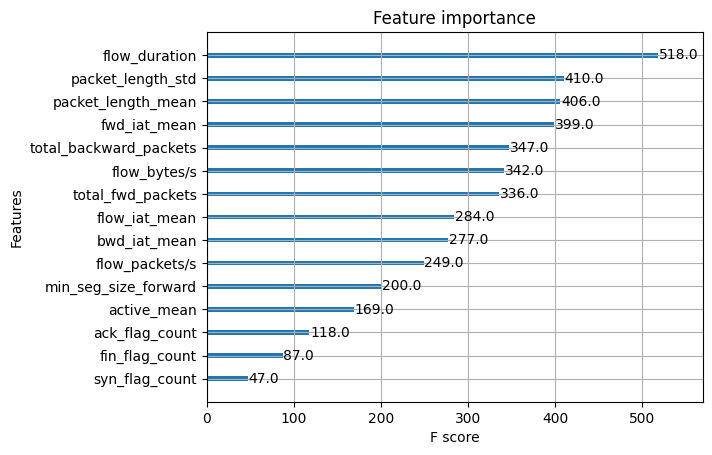

In [ ]:
import matplotlib.pyplot as plt
xgb.plot_importance(model)
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
import xgboost as xgb
import numpy as np

In [ ]:
X = df.drop('label', axis=1)
y = df['label']

# Replace inf and fill missing values
X = X.replace([float('inf'), -float('inf')], pd.NA)
X = X.fillna(0)


<ipython-input-42-60a755b51f9d>:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X = X.fillna(0)


In [ ]:
model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')


In [ ]:
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
cv_scores = cross_val_score(model, X, y, cv=kfold, scoring='accuracy', n_jobs=-1)


In [ ]:
print(f"Cross-Validation Accuracy Scores: {cv_scores}")
print(f"Mean Accuracy: {np.mean(cv_scores):.4f}")
print(f"Standard Deviation: {np.std(cv_scores):.4f}")

Cross-Validation Accuracy Scores: [0.98605616 0.98590797 0.9862492  0.98596179 0.98624471]
Mean Accuracy: 0.9861
Standard Deviation: 0.0001
